In [2]:
%%writefile going_modular/helper_func.py

import os
from sklearn.model_selection import train_test_split
import shutil
import random
from scipy.io import loadmat

def get_class_names(roots_dir):
    meta_path = os.path.join(roots_dir, 'car_devkit', 'devkit', 'cars_meta.mat')
    meta = loadmat(meta_path, squeeze_me=True)
    class_names = [str(name) for name in meta['class_names']]
    return class_names


def load_annotations(root_dir, split='train'):
    if split == 'train':
        annos_path = os.path.join(root_dir, 'car_devkit', 'devkit', 'cars_train_annos.mat')
        img_dir = os.path.join(root_dir, 'cars_train', 'cars_train')
    else:
        annos_path = os.path.join(root_dir, 'car_devkit', 'devkit', 'cars_test_annos_withlabels.mat')
        img_dir = os.path.join(root_dir, 'cars_test', 'cars_test')

    annos = loadmat(annos_path, squeeze_me=True)['annotations']
    samples = []
    for ann in annos:
        fname = ann['fname']
        
        if isinstance(fname, bytes):
            fname = fname.decode('utf-8')
        elif hasattr(fname, '__iter__') and not isinstance(fname, str):
            fname = str(fname[0])

        img_path = os.path.join(img_dir, fname)
        label = int(ann['class']) - 1 
        samples.append((img_path, label))
    
    return samples


def create_folder_structure(root_dir, target_dir, selected_indices):
    train_samples = load_annotations(root_dir, 'train')
    test_samples = load_annotations(root_dir, 'test')
    class_names = get_class_names(root_dir)

    selected_set = set(selected_indices)
    filtered_train = [(img, label) for img, label in train_samples if label in selected_set]
    filtered_test = [(img, label) for img, label in test_samples if label in selected_set]

    print(f'после фильтрации train: {len(filtered_train)}, test: {len(filtered_test)}')

    for split in ['train', 'test']:
        os.makedirs(os.path.join(target_dir, split), exist_ok=True)

    for label in selected_indices:
        class_name = class_names[label].replace(' ', '_').replace('/', '_')
        class_dir = f"{label:03d}_{class_name}"

        for split, samples in [('train', filtered_train), ('test', filtered_test)]:
            split_dir = os.path.join(target_dir, split, class_dir)
            os.makedirs(split_dir, exist_ok=True)

            class_samples = [img for img, lbl in samples if lbl == label]

            for img_path in class_samples:
                dst_path = os.path.join(split_dir, os.path.basename(img_path))
                shutil.copy2(img_path, dst_path)

    with open(os.path.join(target_dir, 'classes.txt'), 'w') as f:
        for idx in selected_indices:
            f.write(f'{idx:03d}: {class_names[idx]}\n')










Overwriting going_modular/helper_func.py


In [2]:

from going_modular import helper_func

samples = helper_func.get_class_names('cars')
for indx, name in enumerate(samples):
    print(f'{indx}: {name}')


0: AM General Hummer SUV 2000
1: Acura RL Sedan 2012
2: Acura TL Sedan 2012
3: Acura TL Type-S 2008
4: Acura TSX Sedan 2012
5: Acura Integra Type R 2001
6: Acura ZDX Hatchback 2012
7: Aston Martin V8 Vantage Convertible 2012
8: Aston Martin V8 Vantage Coupe 2012
9: Aston Martin Virage Convertible 2012
10: Aston Martin Virage Coupe 2012
11: Audi RS 4 Convertible 2008
12: Audi A5 Coupe 2012
13: Audi TTS Coupe 2012
14: Audi R8 Coupe 2012
15: Audi V8 Sedan 1994
16: Audi 100 Sedan 1994
17: Audi 100 Wagon 1994
18: Audi TT Hatchback 2011
19: Audi S6 Sedan 2011
20: Audi S5 Convertible 2012
21: Audi S5 Coupe 2012
22: Audi S4 Sedan 2012
23: Audi S4 Sedan 2007
24: Audi TT RS Coupe 2012
25: BMW ActiveHybrid 5 Sedan 2012
26: BMW 1 Series Convertible 2012
27: BMW 1 Series Coupe 2012
28: BMW 3 Series Sedan 2012
29: BMW 3 Series Wagon 2012
30: BMW 6 Series Convertible 2007
31: BMW X5 SUV 2007
32: BMW X6 SUV 2012
33: BMW M3 Coupe 2012
34: BMW M5 Sedan 2010
35: BMW M6 Convertible 2010
36: BMW X3 SUV 201

In [3]:
from going_modular import helper_func
root_dir = 'cars'
target_dir = 'part_cars'
selected_cars = [12, 31, 34, 41, 45, 52, 54, 61, 101, 114, 125, 143, 161, 166, 186]
helper_func.create_folder_structure(root_dir, target_dir, selected_cars)


после фильтрации train: 636, test: 627


In [3]:
%%writefile going_modular/data_setup.py
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

def create_dataloaders(
    train_dir: str,
    test_dir: str,
    train_transforms: transforms.Compose,
    test_transforms: transforms.Compose,
    batch_size: int
):
    train_data = datasets.ImageFolder(root=train_dir, transform=train_transforms)
    test_data = datasets.ImageFolder(root=test_dir, transform=test_transforms)

    train_dataloader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
    test_dataloader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False)

    class_names = train_data.classes
    return train_dataloader, test_dataloader, class_names

Overwriting going_modular/data_setup.py


In [5]:
%%writefile going_modular/cnnBlock.py
from torch import nn

class CNNBlock(nn.Module):
    def __init__(self, in_channels, hidden_units, dropout_p=0.1):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=hidden_units,
            kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
            kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Dropout2d(dropout_p),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units * 2,
            kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units * 2, out_channels=hidden_units * 2,
            kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.Dropout2d(dropout_p),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units * 2, out_channels=hidden_units * 4,
            kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units * 4),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units * 4, out_channels=hidden_units * 4,
            kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units * 4),
            nn.ReLU(),
            nn.Dropout2d(dropout_p),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units * 4, out_channels=hidden_units * 8,
            kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units * 8),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units * 8, out_channels=hidden_units * 8,
            kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units * 8),
            nn.ReLU(),
            nn.Dropout2d(dropout_p),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return x


Overwriting going_modular/cnnBlock.py


In [4]:
%%writefile going_modular/msa_mlp.py
from torch import nn

class MultiheadSelfAttentionBlock(nn.Module):
    def __init__(self, embedding_dim=768,
    num_heads=12, attn_dropout=0):
        super().__init__()
        self.layer_norm = nn.LayerNorm(
            normalized_shape=embedding_dim) 
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=embedding_dim,
            num_heads=num_heads,
            batch_first=True
        )

    def forward(self, x):
        x = self.layer_norm(x)
        attn_output, _ = self.multihead_attn(
            query=x, key=x, value=x, need_weights=False
        )
        return attn_output


class MLPBlock(nn.Module):
    def __init__(self, embedding_dim=128,
    mlp_size=512,
    mlp_dropout=0.1):
        super().__init__()
        self.layer_norm = nn.LayerNorm(
            normalized_shape=embedding_dim)
        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim,
            out_features=mlp_size),
            nn.GELU(),
            nn.Dropout(p=mlp_dropout),
            nn.Linear(in_features=mlp_size,
            out_features=embedding_dim),
            nn.Dropout(p=mlp_dropout)
        )

    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp(x)
        return x


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embedding_dim=128,
    num_heads=4, mlp_size=512, mlp_dropout=0.1, attn_dropout=0):
        super().__init__()
        self.msa_block = MultiheadSelfAttentionBlock(
            embedding_dim=embedding_dim,
            num_heads=num_heads,
            attn_dropout=attn_dropout
        )
        self.mlp_block = MLPBlock(
            embedding_dim=embedding_dim,
            mlp_size=mlp_size,
            mlp_dropout=mlp_dropout)
        
    def forward(self, x):
        x = self.msa_block(x) + x
        x = self.mlp_block(x) + x
        return x

Overwriting going_modular/msa_mlp.py


In [5]:
%%writefile going_modular/transformerBlock.py
from msa_mlp import TransformerEncoderBlock
import torch

class ViT(torch.nn.Module):
    def __init__(self,
    num_patches=196,
    num_transformer_layers=2,
    embedding_dim=128,
    mlp_size=512,
    num_heads=4,
    attn_dropout=0,
    mlp_dropout=0.1,
    embedding_dropout=0.1,
    num_classes=15):
        super().__init__()
        self.class_embedding = torch.nn.Parameter(data=torch.rand(1, 1, embedding_dim), requires_grad=True)
        self.position_embedding = torch.nn.Parameter(data=torch.rand(1, num_patches+1, embedding_dim), requires_grad=True)
        self.embedding_dropout = torch.nn.Dropout(p=embedding_dropout)
        self.transformer_encoder = torch.nn.Sequential(*[TransformerEncoderBlock(
            embedding_dim=embedding_dim,
            num_heads=num_heads,
            mlp_size=mlp_size,
            mlp_dropout=mlp_dropout
        ) for _ in range(num_transformer_layers)])
        self.classifier = torch.nn.Sequential(
            torch.nn.LayerNorm(normalized_shape=embedding_dim),
            torch.nn.Linear(in_features=embedding_dim,
            out_features=num_classes)
        )
    def forward(self, x):
        batch_size = x.shape[0]
        class_token = self.class_embedding.expand(batch_size, -1, -1)
        x = torch.cat((class_token, x), dim=1)
        x = self.position_embedding + x
        x = self.embedding_dropout(x)
        x = self.transformer_encoder(x)
        x = self.classifier(x[:, 0])
        return x


Overwriting going_modular/transformerBlock.py


In [6]:
%%writefile going_modular/resnetBlock.py
from torch import nn
import torchvision.models as models

class ResNetBlock(nn.Module):
    def __init__(self, input_size=224):
        super().__init__()
        backbone = models.resnet18(weights='DEFAULT')
        self.resnet = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
            backbone.layer1,
            backbone.layer2,
            backbone.layer3,
            backbone.layer4
        )
        layer4 = self.resnet[7]
        layer4[0].conv1.stride = (1, 1)
        if layer4[0].downsample is not None:
            layer4[0].downsample[0].stride = (1, 1)
        self.out_channels = 512

    def forward(self, x):
        return self.resnet(x)

Overwriting going_modular/resnetBlock.py


In [7]:
%%writefile going_modular/model_builder.py
from resnetBlock import ResNetBlock
from transformerBlock import ViT
from torch import nn
class HybridModel(nn.Module):
    def __init__(self, in_channels=3, hidden_units=64, 
    num_transformer_layers=2, embedding_dim=128, num_heads=4, mlp_size=512, num_classes=15):
        super().__init__()
        self.cnn = ResNetBlock()
        self.projection = nn.Linear(self.cnn.out_channels, embedding_dim)
        self.transformer = ViT(num_patches=196,
            num_transformer_layers=2,
            embedding_dim=128,
            mlp_size=512,
            num_heads=4,
            attn_dropout=0,
            mlp_dropout=0.1,
            embedding_dropout=0.1,
            num_classes=15)

    def forward(self, x):
        x = self.cnn(x)
        x = x.flatten(2)
        x = x.permute(0, 2, 1)
        x = self.projection(x)
        x = self.transformer(x)    
        return x    

Overwriting going_modular/model_builder.py


In [31]:
model = HybridModel()
model

HybridModel(
  (cnn): CNNBlock(
    (block1): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Dropout2d(p=0.1, inplace=False)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Dropout2d(p=0.1, inpla

In [32]:
from torchinfo import summary
summary(model=model,
input_size=(1, 3, 224, 224),
col_names=["input_size", "output_size", "num_params", "trainable"],
col_width=20,
row_settings=["var_names"])

Layer (type (var_name))                                           Input Shape          Output Shape         Param #              Trainable
HybridModel (HybridModel)                                         [1, 3, 224, 224]     [1, 15]              --                   True
├─CNNBlock (cnn)                                                  [1, 3, 224, 224]     [1, 512, 14, 14]     --                   True
│    └─Sequential (block1)                                        [1, 3, 224, 224]     [1, 64, 112, 112]    --                   True
│    │    └─Conv2d (0)                                            [1, 3, 224, 224]     [1, 64, 224, 224]    1,792                True
│    │    └─BatchNorm2d (1)                                       [1, 64, 224, 224]    [1, 64, 224, 224]    128                  True
│    │    └─ReLU (2)                                              [1, 64, 224, 224]    [1, 64, 224, 224]    --                   --
│    │    └─Conv2d (3)                                     

In [8]:
%%writefile going_modular/engine.py
import torch
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter

def train_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device
):
    model.train()
    train_loss_sum, train_acc = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        optimizer.zero_grad()
        X, y = X.to(device), y.to(device)
        log = model(X)
        loss = loss_fn(log, y)
        y_pred = torch.softmax(log, dim=1).argmax(dim=1)
        train_loss_sum += loss.item() * X.size(0)
        train_acc += (y_pred == y).sum().item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
    avg_train_loss = train_loss_sum / len(dataloader.dataset)
    avg_train_acc = train_acc / len(dataloader.dataset) * 100
    return avg_train_loss, avg_train_acc


def test_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    device: torch.device
):
    model.eval()
    test_loss_sum, test_acc = 0, 0
    with torch.inference_mode():
        model.eval()
        for (X, y) in dataloader:
            X, y = X.to(device), y.to(device)
            log = model(X)
            test_loss_sum += loss_fn(log, y).item() * X.size(0)
            y_pred = torch.softmax(log, dim=1).argmax(dim=1)
            test_acc += (y_pred == y).sum().item()
    avg_test_loss = test_loss_sum / len(dataloader.dataset)
    avg_test_acc = test_acc / len(dataloader.dataset) * 100
    return avg_test_loss, avg_test_acc


def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device,
          ):
    writer = SummaryWriter()

    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
    }
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device)
        test_loss, test_acc = test_step(model=model,
        dataloader=test_dataloader,
        loss_fn=loss_fn,
        device=device)
    
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
            )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        if writer:

            writer.add_scalars(main_tag="Loss", 
                                tag_scalar_dict={"train_loss": train_loss,
                                                    "test_loss": test_loss},
                                global_step=epoch)

            writer.add_scalars(main_tag="Accuracy", 
                                tag_scalar_dict={"train_acc": train_acc,
                                                    "test_acc": test_acc}, 
                                global_step=epoch)
            writer.close()
        else:
            pass
    return results


        


Overwriting going_modular/engine.py


In [34]:
%%writefile going_modular/utils.py

import torch
from pathlib import Path

def save_model(
    model: torch.nn.Module,
    target_dir: str,
    model_name: str
):
    target_dir_path = Path(target_dir)
    target_dir_path.mkdir(parents=True, exist_ok=True)
    assert model_name.endswith('.pth') or model_name.endswith('.pt'), "model_name should end with '.pt' or '.pth'"
    model_save_path = target_dir_path / model_name
    print(f"[INFO] Saving model to: {model_save_path}")
    torch.save(obj=model.state_dict(),
             f=model_save_path)

Writing going_modular/utils.py


In [9]:
%%writefile going_modular/train.py
from model_builder import HybridModel
import pickle
import torch
import argparse
import data_setup, engine, utils
from torchvision import transforms

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--epochs', type=int, default=10)
    parser.add_argument('--lr', type=float, default=0.001)
    parser.add_argument('--batch_size', type=int, default=64)
    parser.add_argument('--hidden_units', type=int, default=64)
    parser.add_argument('--num_transformer_layers', type=int, default=2)
    parser.add_argument('--embedding_dim', type=int, default=128)
    parser.add_argument('--num_heads', type=int, default=4)
    parser.add_argument('--mlp_size', type=int, default=512)
    args = parser.parse_args()

    train_dir = 'part_cars/train'
    test_dir = 'part_cars/test'

    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]

    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    data_transform_train = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    data_transform_test = transforms.Compose([
        transforms.Resize(size=(224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    train_transforms=data_transform_train,
    test_transforms=data_transform_test,
    batch_size=args.batch_size
)

    model = HybridModel(hidden_units=args.hidden_units,
    num_transformer_layers=args.num_transformer_layers,
    embedding_dim=args.embedding_dim, 
    num_heads=args.num_heads,
    mlp_size=args.mlp_size).to(device)

    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)

    results = engine.train(model=model,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=args.epochs,
                device=device
    )

    with open('training_results.pkl', 'wb') as f:
        pickle.dump(results, f)

    utils.save_model(
        model=model,
        target_dir='models',
        model_name='first_try.pth'
    )

if __name__ == '__main__':
    main()
    
    

Overwriting going_modular/train.py


In [1]:
import sys
import os

project_root = os.path.dirname(os.getcwd())
if not os.path.exists(os.path.join(project_root, 'going_modular')):
    project_root = os.getcwd()

modular_path = os.path.join(project_root, 'going_modular')
if modular_path not in sys.path:
    sys.path.insert(0, modular_path)

print(f"✅ Добавлен путь: {modular_path}")

✅ Добавлен путь: c:\Users\avmor\Desktop\forlearning\going_modular


In [ ]:
import torch
from model_builder import HybridModel

# Создаём модель
model = HybridModel(
    num_classes=15,
    hidden_units=64,
    num_transformer_layers=4,
    embedding_dim=128,
    num_heads=4,
    mlp_size=512
)

# Загружаем веса
model.load_state_dict(torch.load('going_modular/models/first_try.pth'))
model.eval()

print("✅ Модель загружена!")


✅ Модель загружена!


In [3]:
%%writefile going_modular/confusion_matrix.py
import torchmetrics
import seaborn as sns
import matplotlib.pyplot as plt
import torch

def create_confusion_matrix(model, dataloader, class_names):
    
    all_preds = []
    all_labels = []
    device = 'cpu'
    model.to(device)
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            logits = model(X)
            preds = logits.argmax(dim=1)
            all_preds.append(preds)
            all_labels.append(y)
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    num_classes = len(class_names)
    confmat = torchmetrics.ConfusionMatrix(task='multiclass', num_classes=num_classes)
    confusion_matrix = confmat(all_preds, all_labels)
    conf_matrix_np = confusion_matrix.cpu().numpy()
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix_np, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Предсказанные метки')
    plt.ylabel('Истинные метки')
    plt.title('Матрица ошибок')
    plt.show()

Overwriting going_modular/confusion_matrix.py


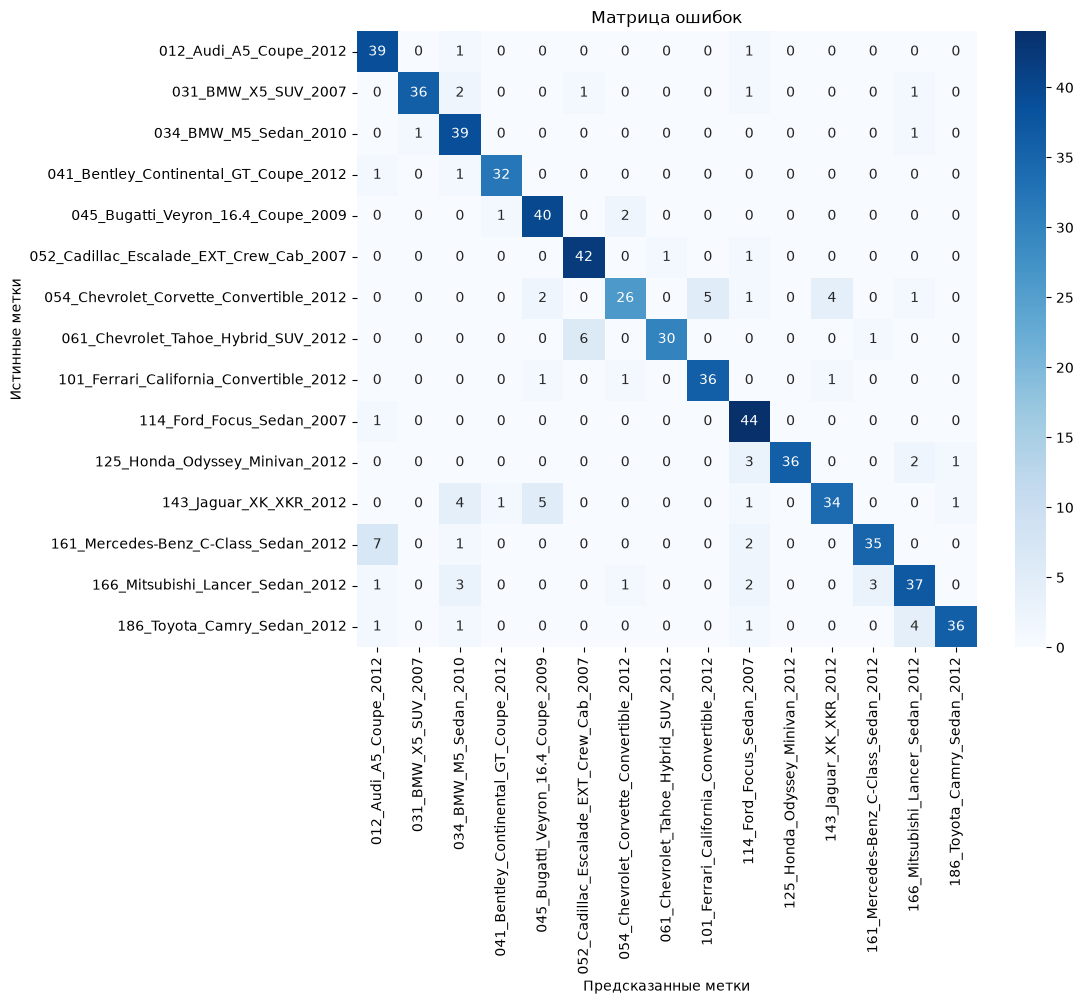

In [4]:
from going_modular.confusion_matrix import create_confusion_matrix
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
test_dir = 'going_modular/part_cars/test'

test_transforms = transforms.Compose([
        transforms.Resize(size=(224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

test_data = datasets.ImageFolder(root=test_dir, transform=test_transforms)

test_dataloader = DataLoader(dataset=test_data, batch_size=32, shuffle=False)

class_names = test_data.classes
create_confusion_matrix(model, test_dataloader, class_names)

In [5]:
import gradio
model.to('cpu')

c:\Users\avmor\Desktop\forlearning\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HybridModel(
  (cnn): ResNetBlock(
    (resnet): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e

In [6]:
from timeit import default_timer as timer
import torch

def predict(img):
    start_time = timer()
    img = test_transforms(img).unsqueeze(0)
    model.eval()
    with torch.inference_mode():
        pred_probs = torch.softmax(model(img), dim=1)
    pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}
    pred_time = round(start_time - timer(), 5)
    return pred_labels_and_probs, pred_time

In [8]:
import random
from PIL import Image
from pathlib import Path

# Get a list of all test image filepaths
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))

# Randomly select a test image path
random_image_path = random.sample(test_data_paths, k=1)[0]

# Open the target image
image = Image.open(random_image_path)
print(f"[INFO] Predicting on image at path: {random_image_path}\n")

# Predict on the target image and print out the outputs
pred_dict, pred_time = predict(img=image)
print(f"Prediction label and probability dictionary: \n{pred_dict}")
print(f"Prediction time: {pred_time} seconds")

[INFO] Predicting on image at path: going_modular\part_cars\test\031_BMW_X5_SUV_2007\02920.jpg

Prediction label and probability dictionary: 
{'012_Audi_A5_Coupe_2012': 0.0053586955182254314, '031_BMW_X5_SUV_2007': 0.8908643126487732, '034_BMW_M5_Sedan_2010': 0.05350091680884361, '041_Bentley_Continental_GT_Coupe_2012': 0.0030265790410339832, '045_Bugatti_Veyron_16.4_Coupe_2009': 0.004113947506994009, '052_Cadillac_Escalade_EXT_Crew_Cab_2007': 0.0023511594627052546, '054_Chevrolet_Corvette_Convertible_2012': 0.008249451406300068, '061_Chevrolet_Tahoe_Hybrid_SUV_2012': 0.0014746473170816898, '101_Ferrari_California_Convertible_2012': 0.0013511517317965627, '114_Ford_Focus_Sedan_2007': 0.006862683221697807, '125_Honda_Odyssey_Minivan_2012': 0.0050508719868958, '143_Jaguar_XK_XKR_2012': 0.0037982703652232885, '161_Mercedes-Benz_C-Class_Sedan_2012': 0.0057754432782530785, '166_Mitsubishi_Lancer_Sedan_2012': 0.000658745295368135, '186_Toyota_Camry_Sedan_2012': 0.007563028018921614}
Predicti

In [9]:
import random

example_list = [[str(filepath)] for filepath in random.sample(test_data_paths, k=3)]
example_list

[['going_modular\\part_cars\\test\\012_Audi_A5_Coupe_2012\\00302.jpg'],
 ['going_modular\\part_cars\\test\\101_Ferrari_California_Convertible_2012\\03535.jpg'],
 ['going_modular\\part_cars\\test\\114_Ford_Focus_Sedan_2007\\06491.jpg']]

In [10]:
title = "Auto predict"
description = "Resnet + CNN model auto classifier."
article = "please do correct predictions."
demo = gradio.Interface(fn=predict,
inputs=gradio.Image(type='pil'),
outputs=[gradio.Label(num_top_classes=3, label='Predictions'),
gradio.Number(label='Prediction time')],
examples=example_list,
title=title,
description=description,
article=article
)

demo.launch(debug=False, share=False)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [15]:

import numpy as np

def get_predictions(model, dataloader, device='cuda'):
    model.eval().to(device)
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            
            probs = torch.softmax(outputs, dim=1)
            
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

y_pred, y_true, y_probs = get_predictions(model, test_dataloader)

round(accuracy_score(y_true, y_pred), 4)

0.8644

In [17]:
precision_score(y_true, y_pred, average='macro')

0.8759973238405003

In [19]:
recall_score(y_true, y_pred, average='macro')

0.865551258737698

In [20]:
f1_score(y_true, y_pred, average='macro')

0.8654781274301118

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

                                         precision    recall  f1-score   support

                 012_Audi_A5_Coupe_2012       0.78      0.95      0.86        41
                    031_BMW_X5_SUV_2007       0.97      0.88      0.92        41
                  034_BMW_M5_Sedan_2010       0.75      0.95      0.84        41
  041_Bentley_Continental_GT_Coupe_2012       0.94      0.94      0.94        34
     045_Bugatti_Veyron_16.4_Coupe_2009       0.83      0.93      0.88        43
052_Cadillac_Escalade_EXT_Crew_Cab_2007       0.86      0.95      0.90        44
054_Chevrolet_Corvette_Convertible_2012       0.87      0.67      0.75        39
    061_Chevrolet_Tahoe_Hybrid_SUV_2012       0.97      0.81      0.88        37
101_Ferrari_California_Convertible_2012       0.88      0.92      0.90        39
              114_Ford_Focus_Sedan_2007       0.77      0.98      0.86        45
         125_Honda_Odyssey_Minivan_2012       1.00      0.86      0.92        42
                 143_Jaguar